In [28]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [29]:
df = pd.read_csv('product_sales_dataset.csv')
df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [30]:
df.shape

(1000, 8)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-null   int64 
 5   Total_Sales_USD  1000 non-null   int64 
 6   Order_Date       1000 non-null   object
 7   Customer_City    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [32]:
print(df.describe(include='all'))

         Product_ID Product_Name Category    Price_USD  Quantity_Sold  \
count   1000.000000         1000     1000  1000.000000    1000.000000   
unique          NaN           24        6          NaN            NaN   
top             NaN  Tennis Ball   Sports          NaN            NaN   
freq            NaN           56      196          NaN            NaN   
mean    1500.500000          NaN      NaN   253.757000       5.455000   
std      288.819436          NaN      NaN   144.902362       2.964247   
min     1001.000000          NaN      NaN    10.000000       1.000000   
25%     1250.750000          NaN      NaN   126.750000       3.000000   
50%     1500.500000          NaN      NaN   255.000000       5.000000   
75%     1750.250000          NaN      NaN   383.250000       8.000000   
max     2000.000000          NaN      NaN   500.000000      10.000000   

        Total_Sales_USD  Order_Date Customer_City  
count       1000.000000        1000          1000  
unique             

In [33]:
df.isnull().sum()

Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64

In [34]:
df.dropna(subset=['Product_ID', 'Product_Name', 'Category', 'Price_USD', 
                  'Quantity_Sold', 'Total_Sales_USD', 'Order_Date', 'Customer_City'], inplace=True)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df.dropna(subset=['Order_Date'], inplace=True)
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day
df['Weekday'] = df['Order_Date'].dt.day_name()

In [35]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)


Number of duplicate rows: 0


In [36]:
df['Calculated_Total'] = df['Price_USD'] * df['Quantity_Sold']
mismatch = (df['Calculated_Total'] != df['Total_Sales_USD']).sum()
print(f"\nRows where Total_Sales_USD != Price_USD * Quantity_Sold: {mismatch}")
if mismatch > 0:
    df['Total_Sales_USD'] = df['Calculated_Total']  


Rows where Total_Sales_USD != Price_USD * Quantity_Sold: 0


In [37]:
total_revenue = df['Total_Sales_USD'].sum()
total_quantity = df['Quantity_Sold'].sum()
avg_price = df['Price_USD'].mean()
num_orders = df['Product_ID'].count()
unique_products = df['Product_Name'].nunique()
unique_cities = df['Customer_City'].nunique()

In [38]:
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Price per Unit: ${avg_price:.2f}")
print(f"Number of Transactions: {num_orders:,}")
print(f"Unique Products: {unique_products}")
print(f"Unique Cities: {unique_cities}")

Total Revenue: $1,371,032.00
Total Quantity Sold: 5,455
Average Price per Unit: $253.76
Number of Transactions: 1,000
Unique Products: 24
Unique Cities: 5


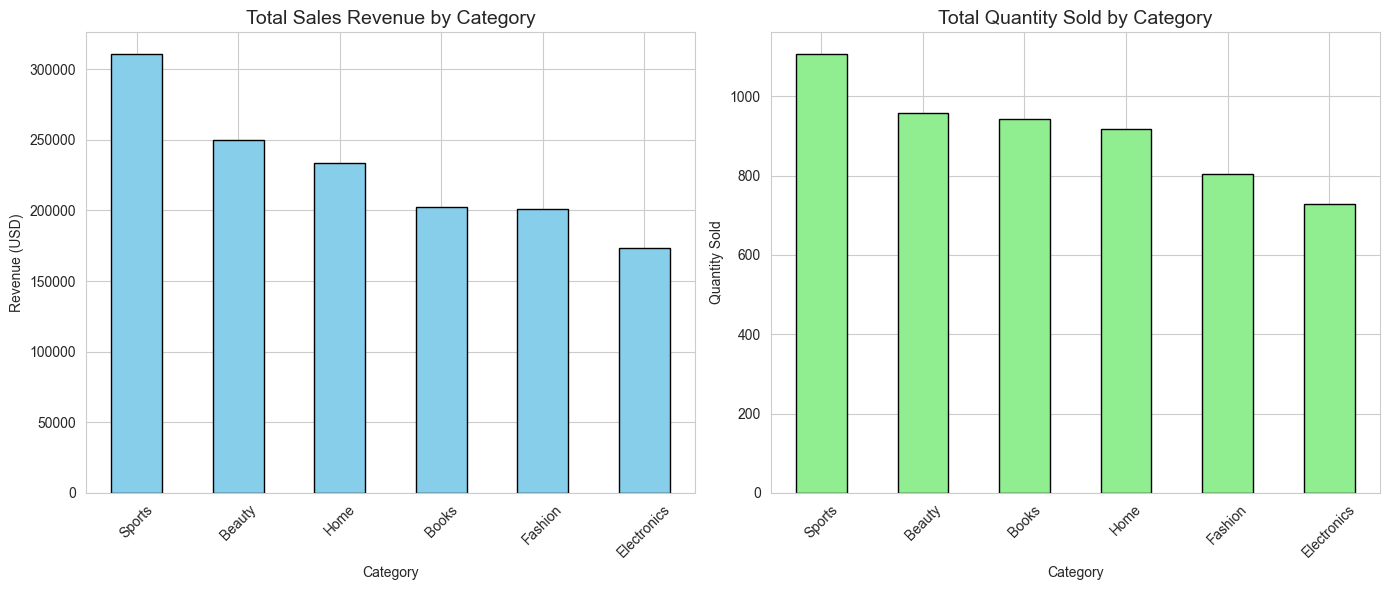

In [39]:
category_sales = df.groupby('Category')['Total_Sales_USD'].sum().sort_values(ascending=False)
category_qty = df.groupby('Category')['Quantity_Sold'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
category_sales.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Total Sales Revenue by Category', fontsize=14)
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=45)

category_qty.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Total Quantity Sold by Category', fontsize=14)
axes[1].set_ylabel('Quantity Sold')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

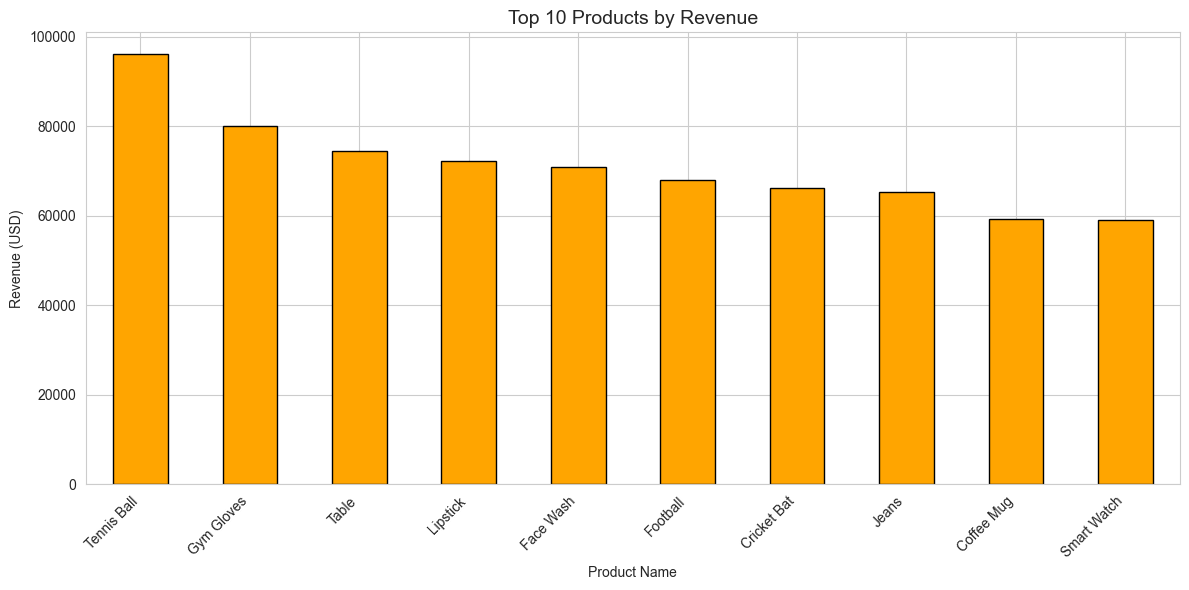

In [40]:
top_products_rev = df.groupby('Product_Name')['Total_Sales_USD'].sum().nlargest(10)
plt.figure(figsize=(12, 6))
top_products_rev.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.ylabel('Revenue (USD)')
plt.xlabel('Product Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

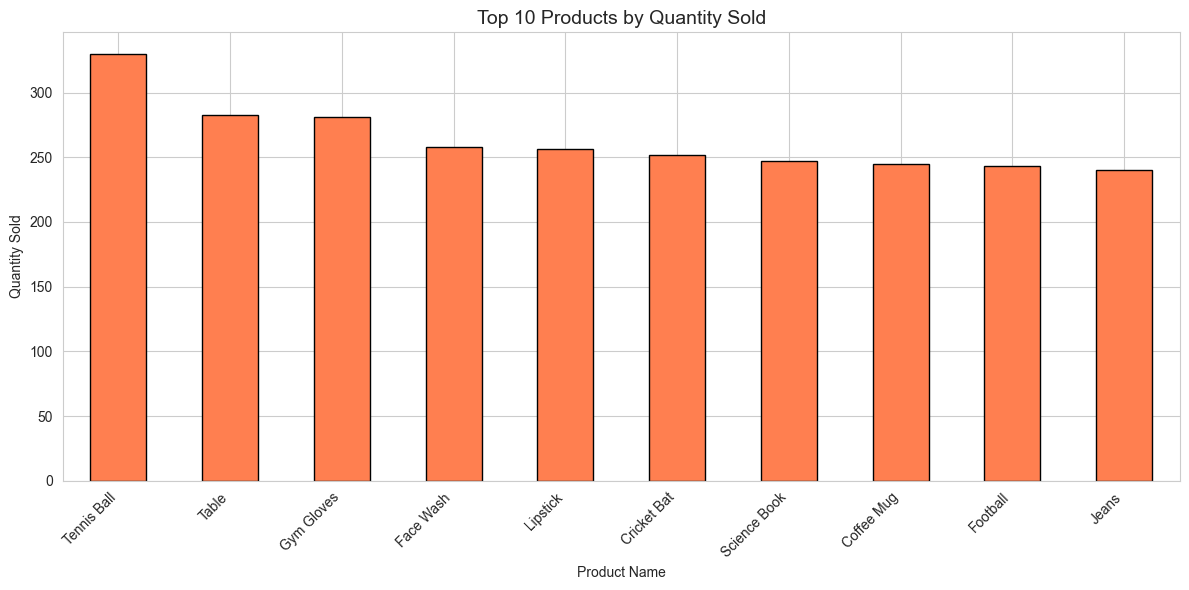

In [41]:
top_products_qty = df.groupby('Product_Name')['Quantity_Sold'].sum().nlargest(10)
plt.figure(figsize=(12, 6))
top_products_qty.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Products by Quantity Sold', fontsize=14)
plt.ylabel('Quantity Sold')
plt.xlabel('Product Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

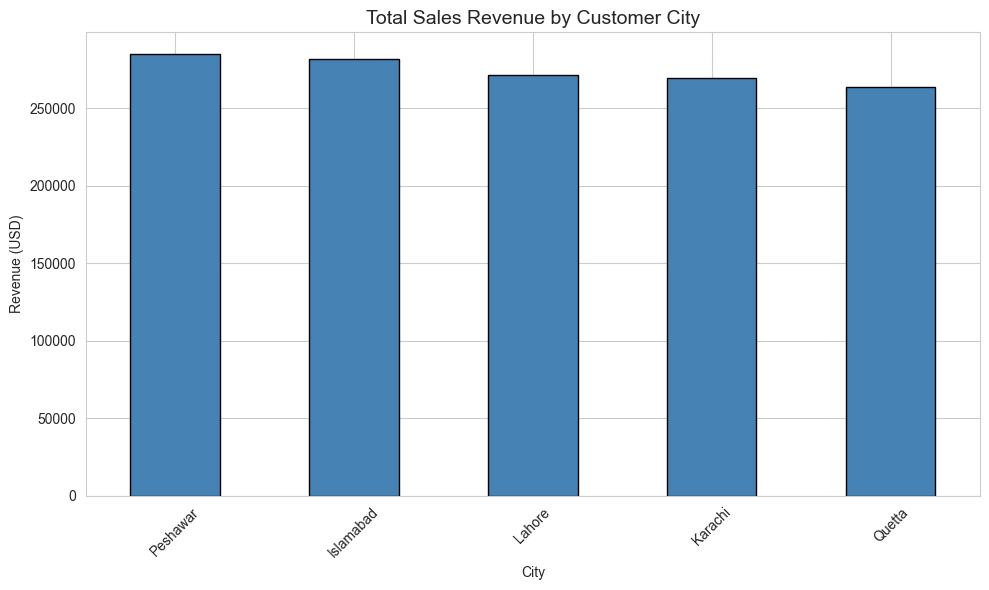

In [42]:
city_sales = df.groupby('Customer_City')['Total_Sales_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
city_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Sales Revenue by Customer City', fontsize=14)
plt.ylabel('Revenue (USD)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

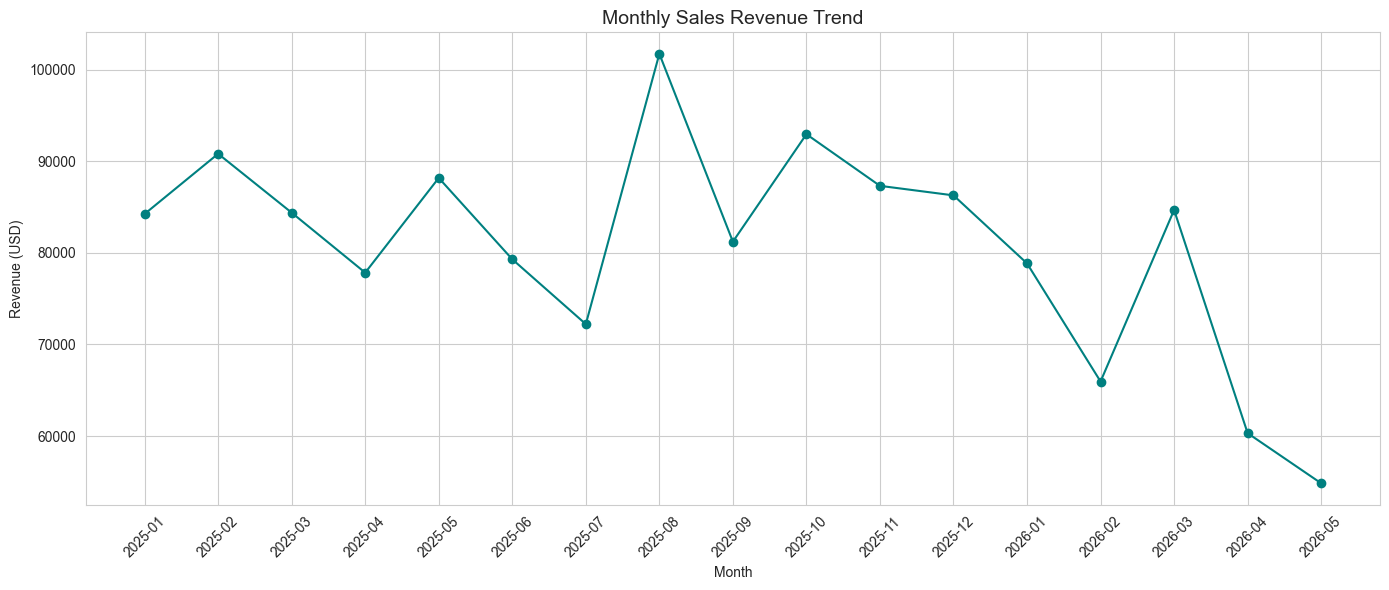

In [43]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales_USD'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='teal')
plt.title('Monthly Sales Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

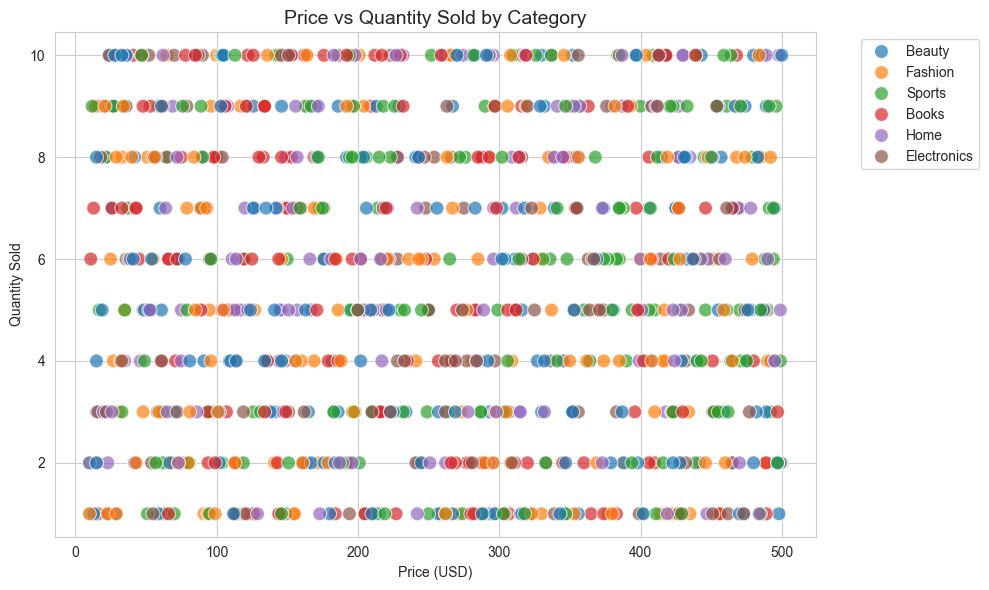

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Price_USD', y='Quantity_Sold', hue='Category', alpha=0.7, s=100)
plt.title('Price vs Quantity Sold by Category', fontsize=14)
plt.xlabel('Price (USD)')
plt.ylabel('Quantity Sold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

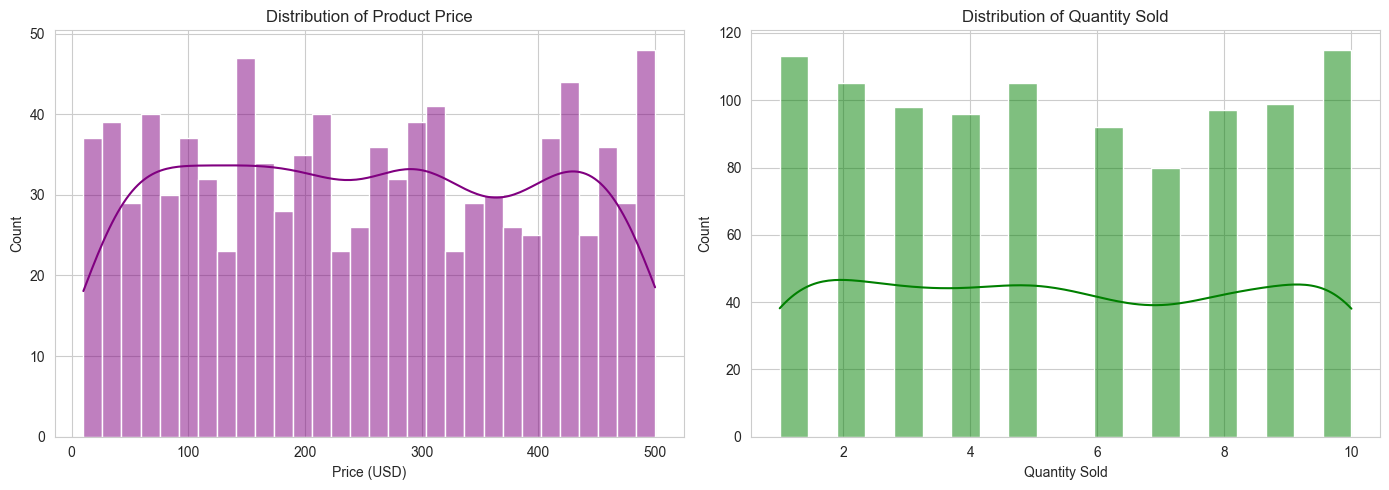

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Price_USD'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Product Price')
axes[0].set_xlabel('Price (USD)')

sns.histplot(df['Quantity_Sold'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Quantity Sold')
axes[1].set_xlabel('Quantity Sold')
plt.tight_layout()
plt.show()

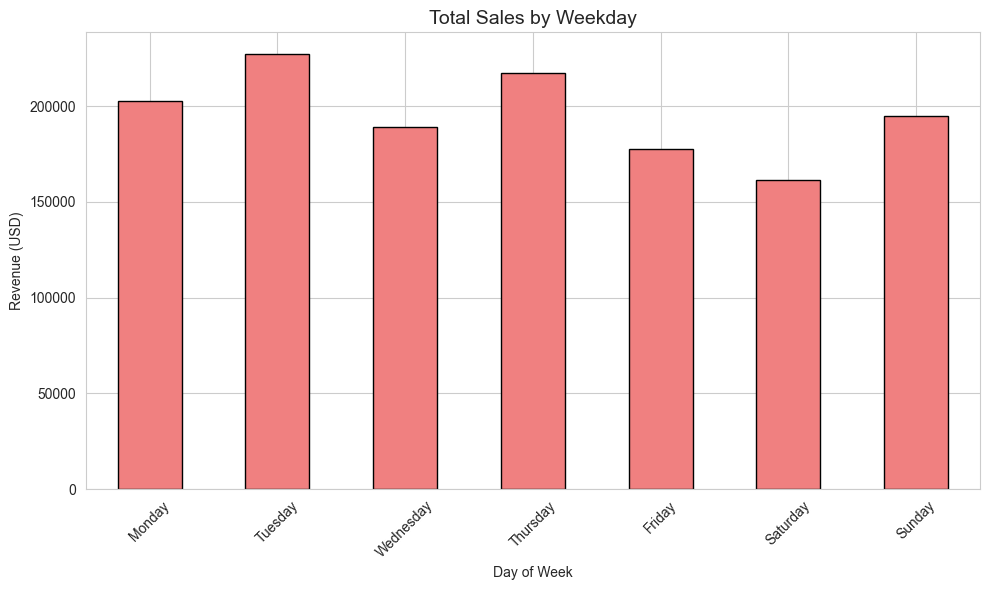

In [46]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Weekday')['Total_Sales_USD'].sum().reindex(weekday_order)

plt.figure(figsize=(10, 6))
weekday_sales.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Total Sales by Weekday', fontsize=14)
plt.ylabel('Revenue (USD)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

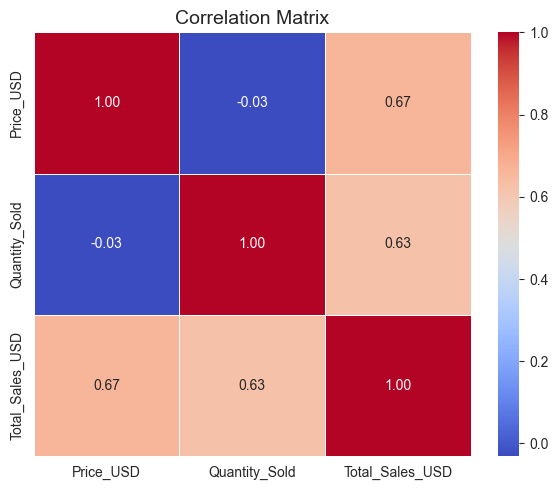

In [47]:
numeric_cols = ['Price_USD', 'Quantity_Sold', 'Total_Sales_USD']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

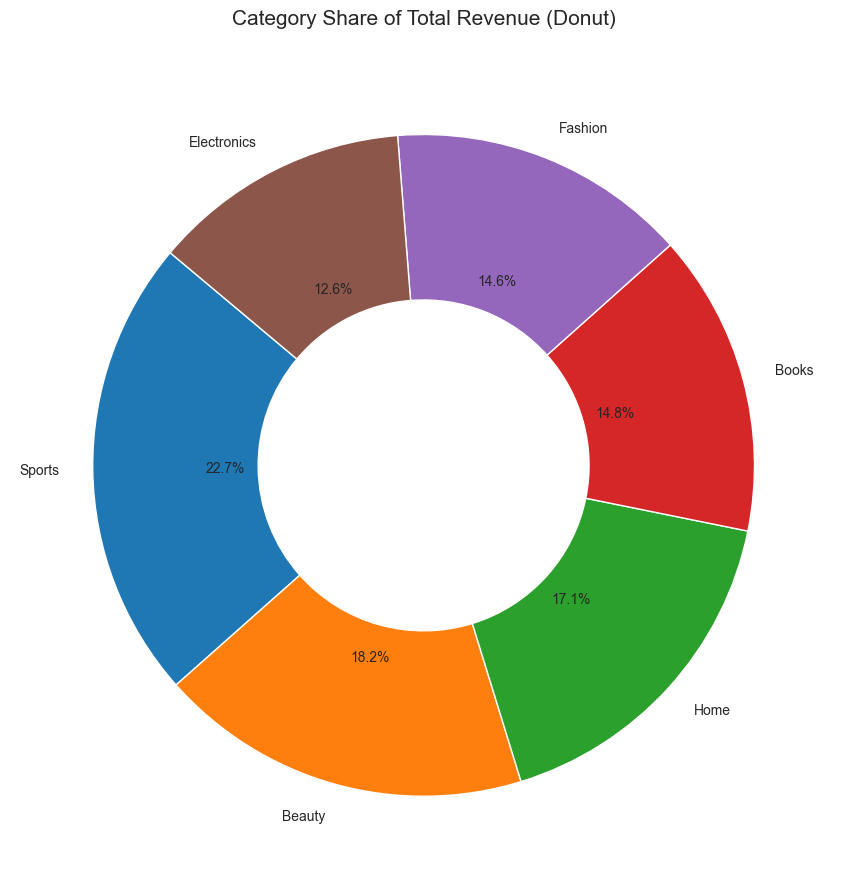

In [48]:
# 1. Category Sales – Donut Chart
category_sales = df.groupby('Category')['Total_Sales_USD'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5),          # donut hole
    colors=sns.color_palette('tab10', len(category_sales))
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Category Share of Total Revenue (Donut)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()


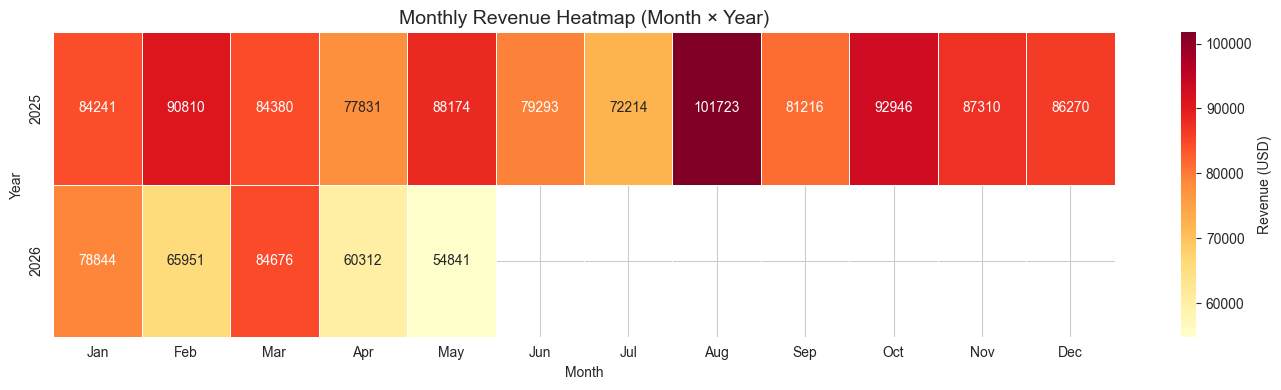

In [49]:
# 2. Monthly Revenue Heatmap (Month × Year)
df['Year']  = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

pivot = df.pivot_table(values='Total_Sales_USD', index='Year', columns='Month', aggfunc='sum')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

plt.figure(figsize=(14, max(4, len(pivot)*1.2)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Revenue (USD)'})
plt.title('Monthly Revenue Heatmap (Month × Year)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


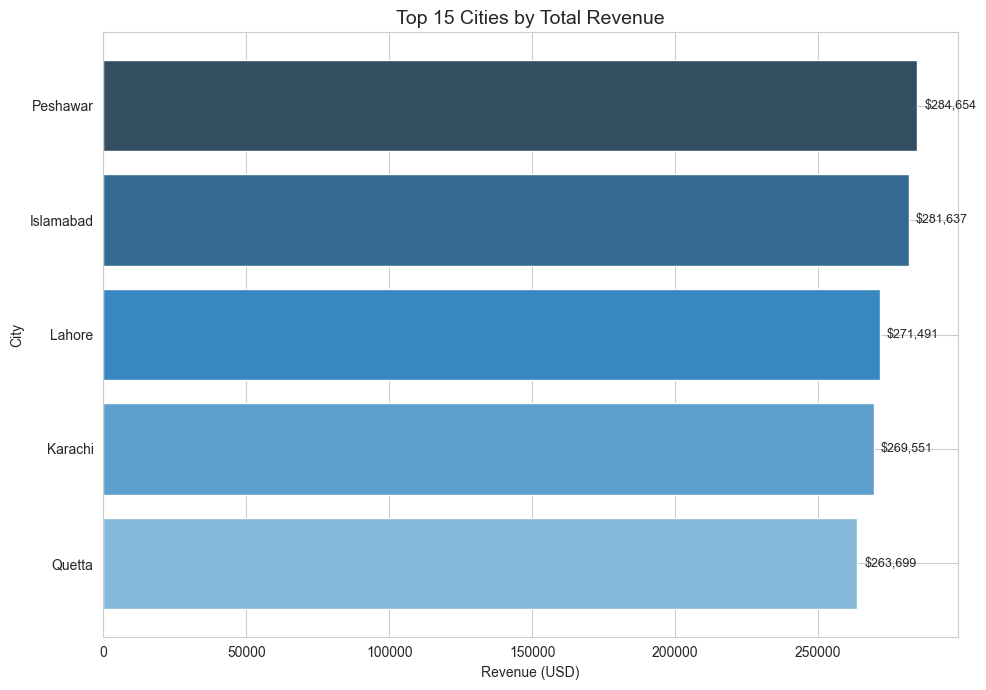

In [50]:
# 3. Top 15 Cities by Revenue – Horizontal Bar
city_sales = df.groupby('Customer_City')['Total_Sales_USD'].sum().nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
bars = plt.barh(city_sales.index, city_sales.values,
                color=sns.color_palette('Blues_d', len(city_sales)))
plt.bar_label(bars, labels=[f'${v:,.0f}' for v in city_sales.values], padding=5, fontsize=9)
plt.title('Top 15 Cities by Total Revenue', fontsize=14)
plt.xlabel('Revenue (USD)')
plt.ylabel('City')
plt.tight_layout()
plt.show()


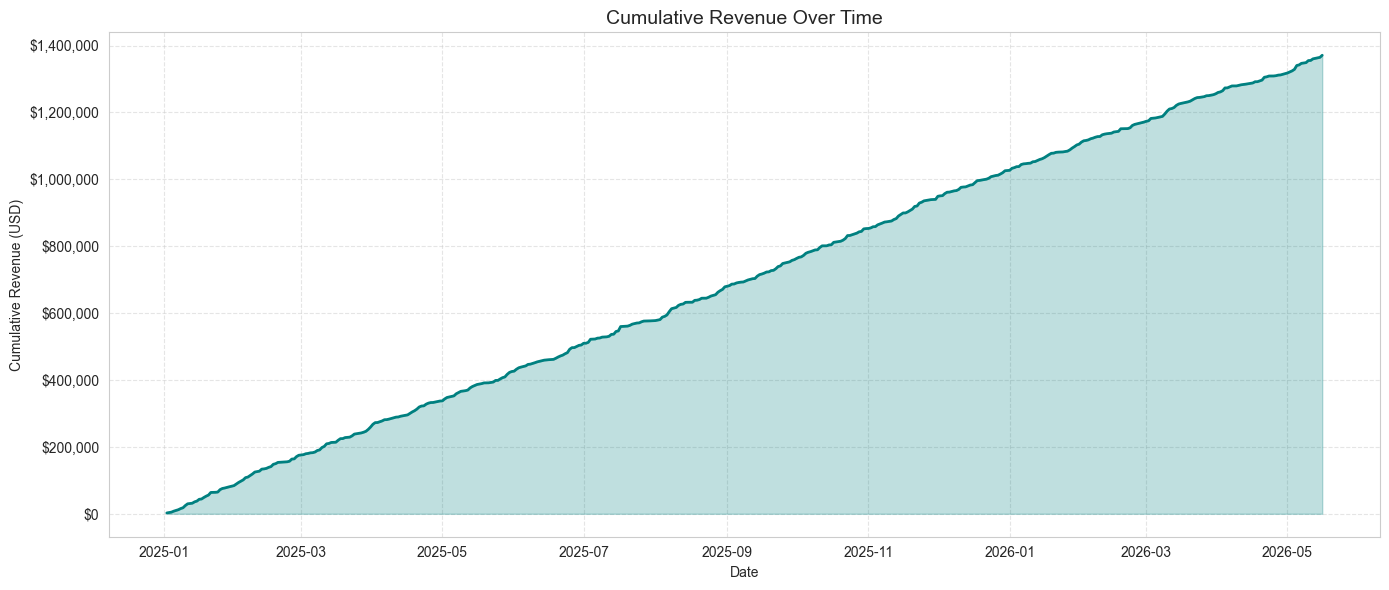

In [51]:
# 4. Cumulative Revenue Over Time
daily_sales = df.groupby('Order_Date')['Total_Sales_USD'].sum().sort_index()
cumulative  = daily_sales.cumsum()

plt.figure(figsize=(14, 6))
plt.fill_between(cumulative.index, cumulative.values, alpha=0.25, color='teal')
plt.plot(cumulative.index, cumulative.values, color='teal', linewidth=2)
plt.title('Cumulative Revenue Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


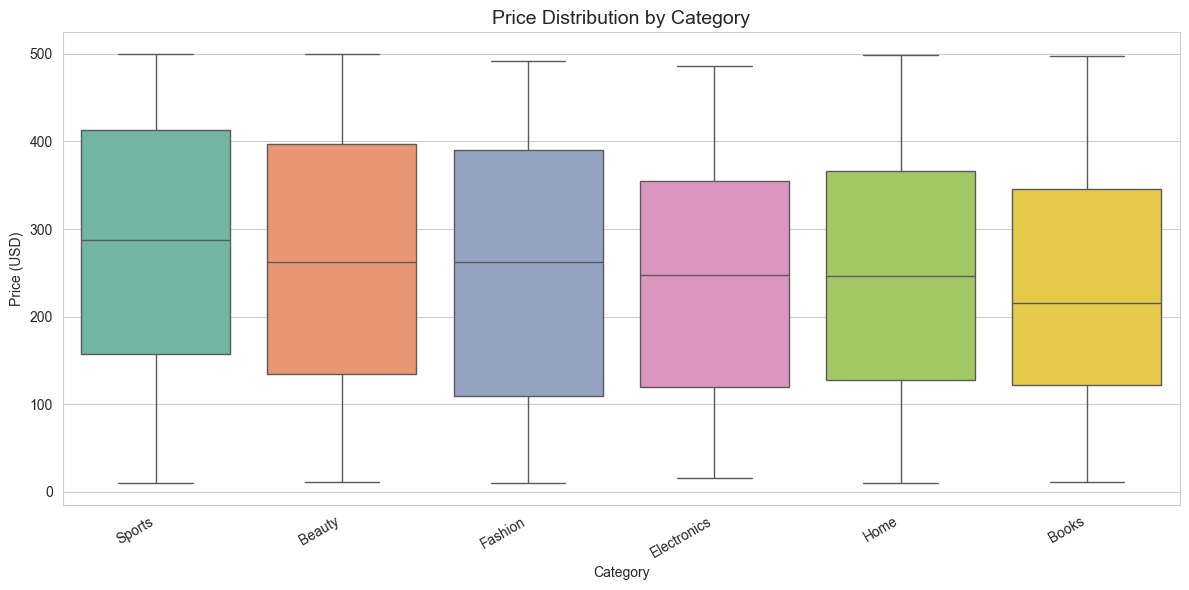

In [52]:
# 5. Price Distribution by Category – Box Plots
order = (df.groupby('Category')['Price_USD']
           .median()
           .sort_values(ascending=False)
           .index)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Category', y='Price_USD', order=order,
            palette='Set2', flierprops=dict(marker='o', markersize=4, alpha=0.5))
plt.title('Price Distribution by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Price (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


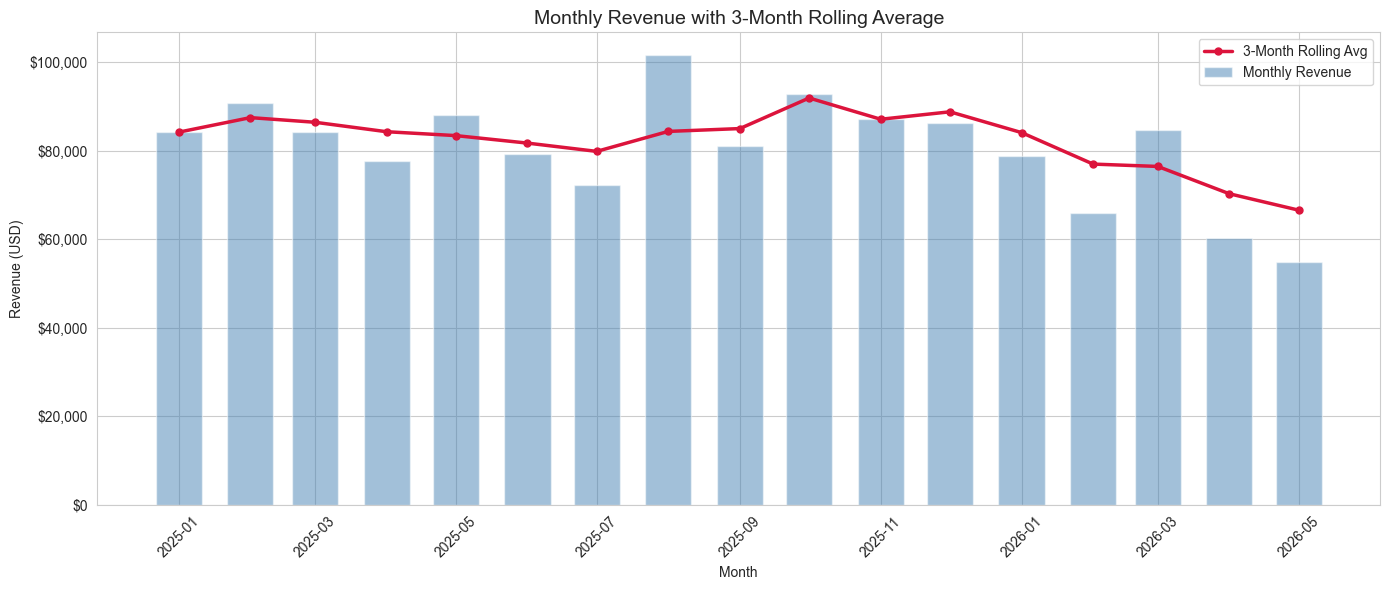

In [53]:
# 6. Monthly Sales with 3-Month Rolling Average Overlay
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales_USD'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
rolling_avg = monthly_sales.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.bar(monthly_sales.index, monthly_sales.values, width=20,
        color='steelblue', alpha=0.5, label='Monthly Revenue')
plt.plot(monthly_sales.index, rolling_avg.values,
         color='crimson', linewidth=2.5, marker='o', markersize=5, label='3-Month Rolling Avg')
plt.title('Monthly Revenue with 3-Month Rolling Average', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


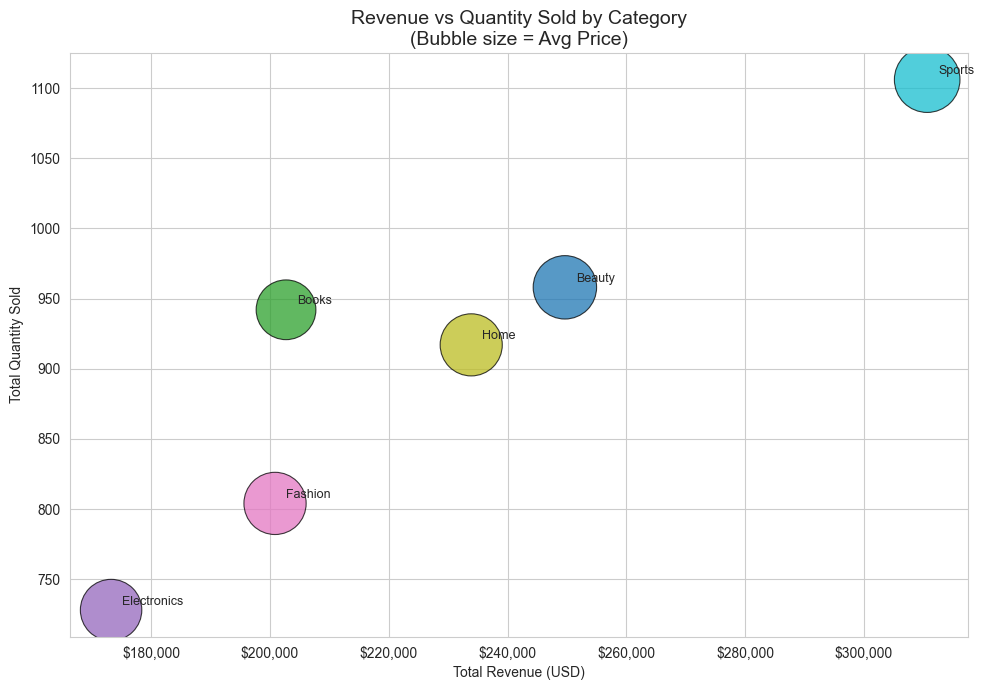

In [54]:
# 7. Revenue vs Quantity Sold – Bubble Chart (bubble = avg price)
bubble_df = (df.groupby('Category')
               .agg(Total_Revenue=('Total_Sales_USD','sum'),
                    Total_Qty=('Quantity_Sold','sum'),
                    Avg_Price=('Price_USD','mean'))
               .reset_index())

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    bubble_df['Total_Revenue'],
    bubble_df['Total_Qty'],
    s=bubble_df['Avg_Price'] * 8,          # bubble size ∝ avg price
    c=range(len(bubble_df)),
    cmap='tab10', alpha=0.75, edgecolors='black', linewidths=0.8
)
for _, row in bubble_df.iterrows():
    plt.annotate(row['Category'],
                 (row['Total_Revenue'], row['Total_Qty']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)
plt.title('Revenue vs Quantity Sold by Category\n(Bubble size = Avg Price)', fontsize=14)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Total Quantity Sold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


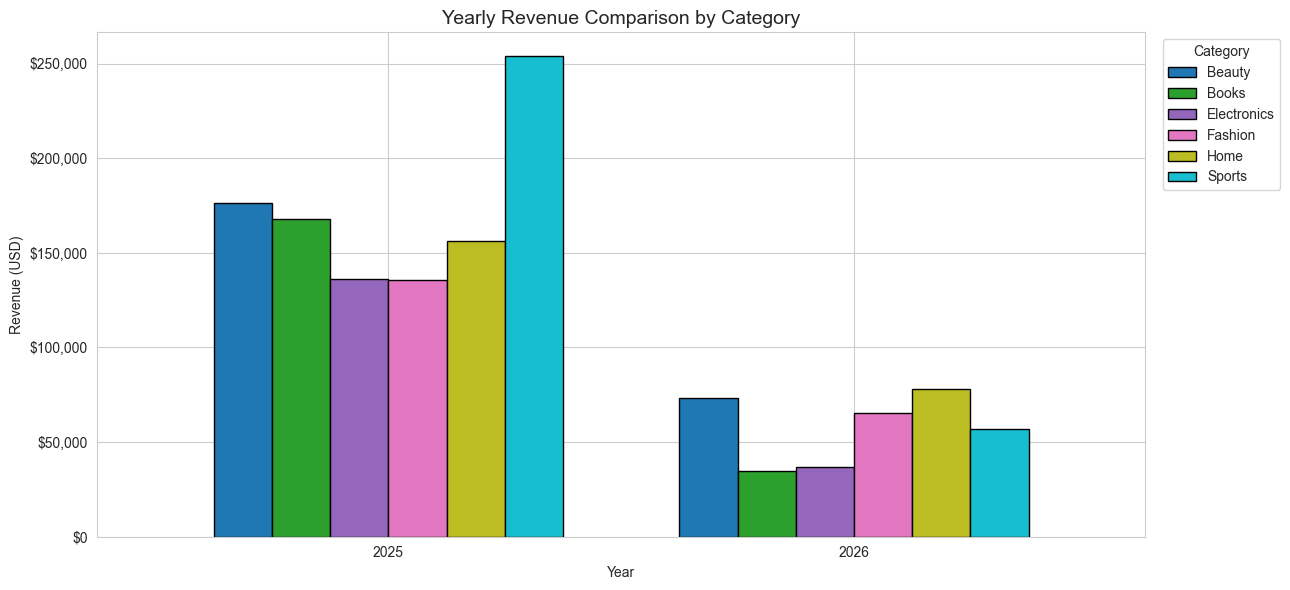

In [55]:
# 8. Yearly Revenue Comparison by Category
yearly_cat = df.groupby(['Year','Category'])['Total_Sales_USD'].sum().unstack(fill_value=0)

ax = yearly_cat.plot(kind='bar', figsize=(13, 6),
                     colormap='tab10', edgecolor='black', width=0.75)
ax.set_title('Yearly Revenue Comparison by Category', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
